In [ ]:
!pip uninstall -y transformers
!pip install transformers==4.40.2 accelerate datasets

Found existing installation: transformers 4.40.2
Uninstalling transformers-4.40.2:
  Successfully uninstalled transformers-4.40.2
  Using cached transformers-4.40.2-py3-none-any.whl.metadata (137 kB)
Using cached transformers-4.40.2-py3-none-any.whl (9.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.2 which is incompatible.


In [ ]:
!pip uninstall -y transformers accelerate datasets huggingface_hub
!pip install --upgrade pip
!pip install transformers accelerate datasets huggingface_hub

Found existing installation: transformers 4.40.2
Uninstalling transformers-4.40.2:
  Successfully uninstalled transformers-4.40.2
Found existing installation: accelerate 1.12.0
Uninstalling accelerate-1.12.0:
  Successfully uninstalled accelerate-1.12.0
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: huggingface_hub 0.36.2
Uninstalling huggingface_hub-0.36.2:
  Successfully uninstalled huggingface_hub-0.36.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 39.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Using cached transformers-5.2.0-py3-none-any.whl.metadata (32 kB)
Using cached transformers-5.2.0-py3-none-any.whl (10.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.3/596.3 kB 20.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 104.6 MB/s  

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 24.6 MB/s eta 0:00:00


In [ ]:
# ================================
# FINAL XLM-RoBERTa GPU TRAINING
# ================================

import pandas as pd
import re
import numpy as np
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

from datasets import Dataset as HFDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

print("Using GPU:", torch.cuda.is_available())

# ==========================
# 1. Load Dataset
# ==========================

train_df = pd.read_csv("train.tsv", sep="\t")
test_df = pd.read_csv("test.tsv", sep="\t")

print("Train size:", len(train_df))
print("Test size:", len(test_df))

# ==========================
# 2. Extract Intent
# ==========================

def extract_intent(parse_text):
    match = re.search(r'\[IN:([A-Z_]+)', parse_text)
    return match.group(1) if match else "UNKNOWN"

train_df['text'] = train_df['cs_query']
test_df['text'] = test_df['cs_query']

train_df['intent'] = train_df['cs_parse'].apply(extract_intent)
test_df['intent'] = test_df['cs_parse'].apply(extract_intent)

# ==========================
# 3. Label Encoding
# ==========================

label_encoder = LabelEncoder()
all_intents = pd.concat([train_df['intent'], test_df['intent']])
label_encoder.fit(all_intents)

train_df['label'] = label_encoder.transform(train_df['intent'])
test_df['label'] = label_encoder.transform(test_df['intent'])

num_labels = len(label_encoder.classes_)
print("Total Intents:", num_labels)

# ==========================
# 4. Convert to HF Dataset
# ==========================

train_hf = HFDataset.from_pandas(train_df[['text','label']])
test_hf = HFDataset.from_pandas(test_df[['text','label']])

# ==========================
# 5. Tokenizer
# ==========================

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

def tokenize(batch):
    return tokenizer(
        batch['text'],
        padding=True,
        truncation=True,
        max_length=80
    )

train_hf = train_hf.map(tokenize, batched=True)
test_hf = test_hf.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ==========================
# 6. Load Model
# ==========================

model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=num_labels
)

# ==========================
# 7. Metrics
# ==========================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

# ==========================
# 8. Training Arguments (Optimized)
# ==========================

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available(),
    logging_steps=100
)

# ==========================
# 9. Trainer
# ==========================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=test_hf,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# ==========================
# 10. Train & Evaluate
# ==========================

trainer.train()

results = trainer.evaluate()

print("\nFinal XLM-R Accuracy:", results["eval_accuracy"])

Using GPU: True
Train size: 2993
Test size: 6513
Total Intents: 64


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Step,Training Loss
100,3.912690
200,3.064034
300,2.267287
400,1.792730
500,1.482101
600,1.298669
700,1.198561
800,1.088050
900,1.018309
1000,1.029967


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Final XLM-R Accuracy: 0.7181022570244127


Train size: 2993
Test size: 6513
Total Intents: 64

Running Logistic Regression...

Logistic Regression Accuracy: 0.742668509135575

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.73      0.75        63
           1       0.00      0.00      0.00        17
           2       0.77      0.91      0.84       622
           3       0.00      0.00      0.00        18
           4       0.67      0.98      0.80       511
           5       0.55      0.83      0.66       193
           6       0.79      0.75      0.77       132
           7       0.90      0.66      0.76       161
           8       0.93      0.47      0.62        58
           9       0.00      0.00      0.00        20
          10       0.88      0.67      0.76       135
          11       0.90      0.28      0.43        92
          12       0.89      0.64      0.74        66
          13       0.86      0.66      0.75        74
          14       0.00      0.0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


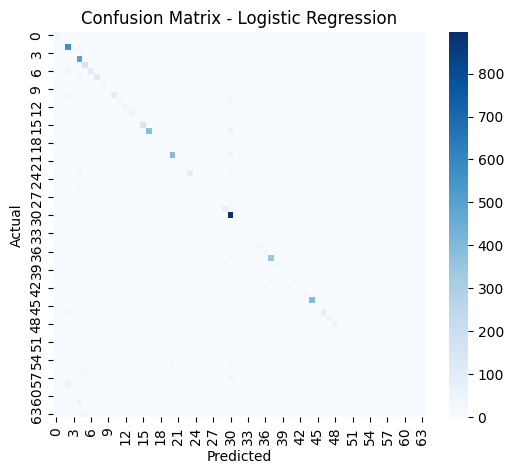

In [3]:
# =========================================
# LOGISTIC REGRESSION BASELINE
# =========================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ==========================
# 1. Load Dataset
# ==========================

train_df = pd.read_csv("train.tsv", sep="\t")
test_df = pd.read_csv("test.tsv", sep="\t")

print("Train size:", len(train_df))
print("Test size:", len(test_df))


# ==========================
# 2. Extract Intent
# ==========================

def extract_intent(parse_text):
    match = re.search(r'\[IN:([A-Z_]+)', parse_text)
    return match.group(1) if match else "UNKNOWN"

train_df['text'] = train_df['cs_query']
test_df['text'] = test_df['cs_query']

train_df['intent'] = train_df['cs_parse'].apply(extract_intent)
test_df['intent'] = test_df['cs_parse'].apply(extract_intent)


# ==========================
# 3. Label Encoding
# ==========================

label_encoder = LabelEncoder()

all_intents = pd.concat([
    train_df['intent'],
    test_df['intent']
])

label_encoder.fit(all_intents)

train_df['label'] = label_encoder.transform(train_df['intent'])
test_df['label'] = label_encoder.transform(test_df['intent'])

num_labels = len(label_encoder.classes_)
print("Total Intents:", num_labels)


# ==========================
# 4. TF-IDF + Logistic Regression
# ==========================

print("\nRunning Logistic Regression...\n")

tfidf = TfidfVectorizer(max_features=3000)

X_train = tfidf.fit_transform(train_df['text'])
X_test = tfidf.transform(test_df['text'])

y_train = train_df['label']
y_test = test_df['label']

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# ==========================
# 5. Confusion Matrix
# ==========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# =========================================
# FASTTEXT + BiLSTM MODEL
# =========================================

import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from gensim.models import FastText
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score


# ==========================
# 1. Load Dataset
# ==========================

train_df = pd.read_csv("train.tsv", sep="\t")
test_df = pd.read_csv("test.tsv", sep="\t")

print("Train size:", len(train_df))
print("Test size:", len(test_df))


# ==========================
# 2. Extract Intent
# ==========================

def extract_intent(parse_text):
    match = re.search(r'\[IN:([A-Z_]+)', parse_text)
    return match.group(1) if match else "UNKNOWN"

train_df['text'] = train_df['cs_query']
test_df['text'] = test_df['cs_query']

train_df['intent'] = train_df['cs_parse'].apply(extract_intent)
test_df['intent'] = test_df['cs_parse'].apply(extract_intent)


# ==========================
# 3. Label Encoding
# ==========================

label_encoder = LabelEncoder()

all_intents = pd.concat([
    train_df['intent'],
    test_df['intent']
])

label_encoder.fit(all_intents)

train_df['label'] = label_encoder.transform(train_df['intent'])
test_df['label'] = label_encoder.transform(test_df['intent'])

num_labels = len(label_encoder.classes_)
print("Total Intents:", num_labels)


# ==========================
# 4. Train FastText Embeddings
# ==========================

train_tokens = [sentence.split() for sentence in train_df['text']]

ft_model = FastText(
    sentences=train_tokens,
    vector_size=50,
    window=3,
    min_count=1,
    workers=2
)

vocab = ft_model.wv.key_to_index
vocab_size = len(vocab)


# ==========================
# 5. Dataset Class
# ==========================

class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=15):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = self.texts[idx].split()
        ids = [self.vocab[word] if word in self.vocab else 0 for word in tokens]
        ids = ids[:self.max_len]
        ids += [0] * (self.max_len - len(ids))
        return torch.tensor(ids), torch.tensor(self.labels[idx])


train_dataset = TextDataset(
    train_df['text'].tolist(),
    train_df['label'].tolist(),
    vocab
)

test_dataset = TextDataset(
    test_df['text'].tolist(),
    test_df['label'].tolist(),
    vocab
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


# ==========================
# 6. BiLSTM Model
# ==========================

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim,
                            bidirectional=True,
                            batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(hidden)


device = torch.device("cpu")

model = BiLSTM(vocab_size, 50, 64, num_labels).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# ==========================
# 7. Training
# ==========================

for epoch in range(2):
    model.train()
    total_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss}")


# ==========================
# 8. Evaluation
# ==========================

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total

print("\nBiLSTM Accuracy:", accuracy)

Train size: 2993
Test size: 6513
Total Intents: 64
Epoch 1, Loss: 305.4024221897125
Epoch 2, Loss: 218.02845406532288

BiLSTM Accuracy: 0.4205435283279595


Using GPU: True
Train size: 2993
Test size: 6513
Total Intents: 64


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/2993 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Step,Training Loss
500,2.171054
1000,0.816399


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Final mBERT Accuracy: 0.8019345923537541


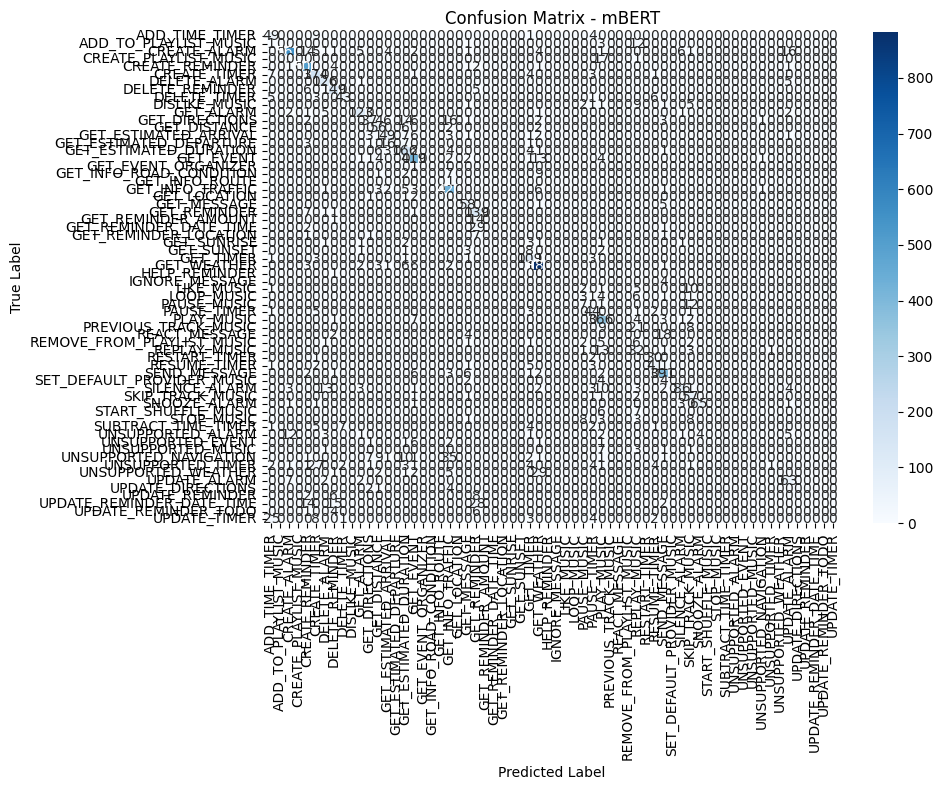

In [3]:
import pandas as pd
import re
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding
from datasets import Dataset as HFDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

print("Using GPU:", torch.cuda.is_available())

# ==========================
# 1. Load Dataset
# ==========================

train_df = pd.read_csv("train.tsv", sep="\t")
val_df = pd.read_csv("validation.tsv", sep="\t")
test_df = pd.read_csv("test.tsv", sep="\t")

print("Train size:", len(train_df))
print("Test size:", len(test_df))

# ==========================
# 2. Extract Intent
# ==========================

def extract_intent(parse_text):
    match = re.search(r'\[IN:([A-Z_]+)', parse_text)
    return match.group(1) if match else "UNKNOWN"

train_df['text'] = train_df['cs_query']
test_df['text'] = test_df['cs_query']

train_df['intent'] = train_df['cs_parse'].apply(extract_intent)
test_df['intent'] = test_df['cs_parse'].apply(extract_intent)

# ==========================
# 3. Label Encoding
# ==========================

label_encoder = LabelEncoder()
all_intents = pd.concat([train_df['intent'], test_df['intent']])
label_encoder.fit(all_intents)

train_df['label'] = label_encoder.transform(train_df['intent'])
test_df['label'] = label_encoder.transform(test_df['intent'])

num_labels = len(label_encoder.classes_)
print("Total Intents:", num_labels)

# ==========================
# 4. Convert to HF Dataset
# ==========================

train_hf = HFDataset.from_pandas(train_df[['text','label']])
test_hf = HFDataset.from_pandas(test_df[['text','label']])

# ==========================
# 5. Tokenization
# ==========================

tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")

def tokenize(batch):
    return tokenizer(
        batch['text'],
        padding=True,
        truncation=True,
        max_length=80
    )

train_hf = train_hf.map(tokenize, batched=True)
test_hf = test_hf.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ==========================
# 6. Load Model
# ==========================

model = BertForSequenceClassification.from_pretrained(
    "bert-base-multilingual-cased",
    num_labels=num_labels
)

# ==========================
# 7. Metrics
# ==========================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

# ==========================
# 8. Training Arguments
# ==========================

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available()
)

# ==========================
# 9. Trainer
# ==========================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=test_hf,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# ==========================
# 10. Train & Evaluate
# ==========================

trainer.train()

results = trainer.evaluate()

print("\nFinal mBERT Accuracy:", results["eval_accuracy"])


# ==========================
# 11. Confusion Matrix
# ==========================

predictions = trainer.predict(test_hf)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - mBERT")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
# =========================================
# USER INPUT INTENT PREDICTION DEMO
# =========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def predict_intent(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=90
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probabilities = torch.nn.functional.softmax(logits, dim=1)

    predicted_class = torch.argmax(probabilities, dim=1).item()
    confidence = torch.max(probabilities).item()

    intent_name = label_encoder.inverse_transform([predicted_class])[0]

    return intent_name, confidence


while True:
    user_input = input("\nEnter a sentence (or type 'exit'): ")

    if user_input.lower() == "exit":
        break

    intent, confidence = predict_intent(user_input)

    print("Predicted Intent:", intent)
    print("Confidence: {:.2f}%".format(confidence * 100))


Enter a sentence (or type 'exit'): kal subah 6 baje alarm laga do
Predicted Intent: CREATE_ALARM
Confidence: 96.66%

Enter a sentence (or type 'exit'): mujhe kal Sharanya se milne yaad dilana
Predicted Intent: CREATE_REMINDER
Confidence: 96.62%

Enter a sentence (or type 'exit'): gaana play karo
Predicted Intent: PLAY_MUSIC
Confidence: 90.04%

Enter a sentence (or type 'exit'): aaj ka weather kya hai
Predicted Intent: GET_WEATHER
Confidence: 97.93%

Enter a sentence (or type 'exit'): Karthik ko message bhejo
Predicted Intent: SEND_MESSAGE
Confidence: 95.48%

Enter a sentence (or type 'exit'): exit


In [ ]:
from google.colab import drive
drive.mount('/content/drive')